Step 1:Load the CSV
I am importing the pandas library using pd.read_csv to load the dataset into a DataFrame called df. I will use df.head() to confirm the data loaded correctly. 

In [1]:
import pandas as pd
df = pd.read_csv("results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


Basic Exploration

In this section, I am exploring the dataset to find:
* The total number of matches using df.shape. * The timeframe of the data using df["date"].min() and .max(). * The number of unique countries in the dataset. * Which team has hosted the most matches using value_counts().

In [2]:
# How many matches are in the dataset?
total_matches = df.shape[0]
print(f"Total matches: {total_matches}")

# What is the earliest and latest year in the data?
# We convert the date column to datetime first to be safe
df['date'] = pd.to_datetime(df['date'])
earliest = df['date'].dt.year.min()
latest = df['date'].dt.year.max()
print(f"Timeframe: {earliest} to {latest}")

# How many unique countries are there?
unique_countries = df['country'].nunique()
print(f"Unique countries: {unique_countries}")

# Which team appears most frequently as home team?
top_home_team = df['home_team'].value_counts().idxmax()
print(f"Most frequent home team: {top_home_team}")

Total matches: 49287
Timeframe: 1872 to 2026
Unique countries: 269
Most frequent home team: Brazil


Goals Analysis

In this section, I am calculating the total goals for every match and analyzing scoring patterns. I will create a new column total_goals by summing home_score and away_score.I will find the average goals per match. I will identify the highest scoring match in history. I will compare total home goals vs. away goals to see where more goals are scored.I will find the most common score (mode) for total goals.

In [4]:
# Create total goals column
df["total_goals"] = df["home_score"] + df["away_score"]

# 1. What is the average number of goals per match?
avg_goals = df["total_goals"].mean()
print(f"Average goals per match: {avg_goals:.2f}")

# 2. What is the highest scoring match?
max_goals = df["total_goals"].max()
highest_match = df[df["total_goals"] == max_goals]
print(f"Highest scoring match: {max_goals} goals")
print(highest_match[['date', 'home_team', 'away_team', 'home_score', 'away_score']])

# 3. Are more goals scored at home or away?
total_home = df["home_score"].sum()
total_away = df["away_score"].sum()
print(f"Total Home Goals: {total_home}")
print(f"Total Away Goals: {total_away}")

# 4. What is the most common total goals value?
common_goals = df["total_goals"].mode()[0]
print(f"Most common total goals in a match: {common_goals}")

Average goals per match: 2.94
Highest scoring match: 31.0 goals
            date  home_team       away_team  home_score  away_score
25420 2001-04-11  Australia  American Samoa        31.0         0.0
Total Home Goals: 86426.0
Total Away Goals: 58192.0
Most common total goals in a match: 2.0


Match Results

In this section, I am defining the outcome of each match to calculate win statistics.  I will create a function to label matches as "Home Win", "Away Win", or "Draw".  I will calculate the percentage of home wins to investigate if a home advantage exists.  I will determine which country has recorded the most wins in international football history.

In [5]:
# Create match outcome function
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

# Apply the function to the dataframe
df["result"] = df.apply(match_result, axis=1)

# 1. What percentage of matches are home wins?
win_pct = df["result"].value_counts(normalize=True) * 100
print(f"Home Win Percentage: {win_pct['Home Win']:.2f}%")

# 2. Does home advantage exist?
away_pct = win_pct['Away Win']
print(f"Away Win Percentage: {away_pct:.2f}%")
print("Conclusion: Home advantage exists as home teams win significantly more often than away teams.")

# 3. Which country has the most wins historically?
# We identify the winner for every row
df['winner'] = df.apply(lambda x: x['home_team'] if x['result'] == 'Home Win' 
                        else (x['away_team'] if x['result'] == 'Away Win' else 'None'), axis=1)

# Count wins (excluding 'None' for draws)
top_winner = df[df['winner'] != 'None']['winner'].value_counts().idxmax()
total_wins = df[df['winner'] != 'None']['winner'].value_counts().max()

print(f"Country with most wins: {top_winner} ({total_wins} wins)")

Home Win Percentage: 48.91%
Away Win Percentage: 28.23%
Conclusion: Home advantage exists as home teams win significantly more often than away teams.
Country with most wins: Brazil (670 wins)


Visualization

In this final section, I will create visual representations of the data:  Histogram of goals: To see the distribution of how many goals are typically scored per match.  Bar chart of match outcomes: To visually compare Home Wins, Away Wins, and Draws.   Top 10 teams by total wins: A bar chart showing the most successful international teams. 

Matplotlib is building the font cache; this may take a moment.


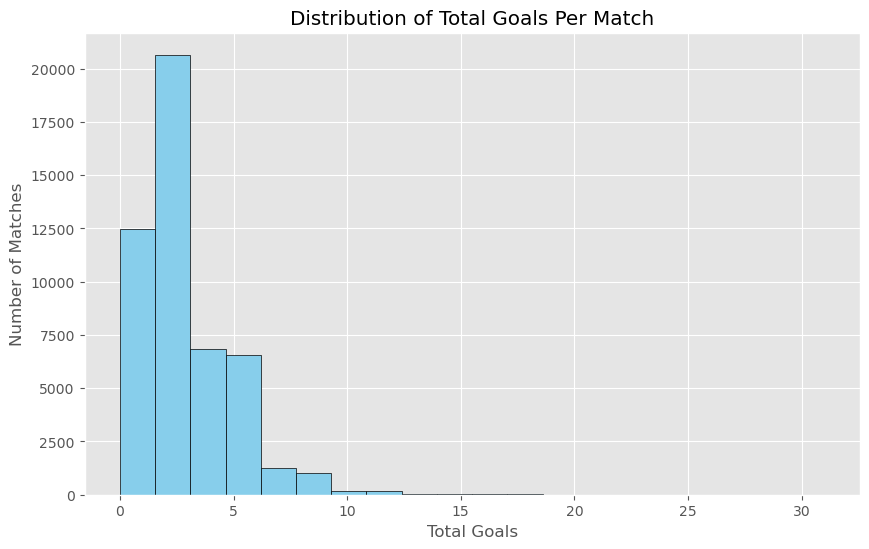

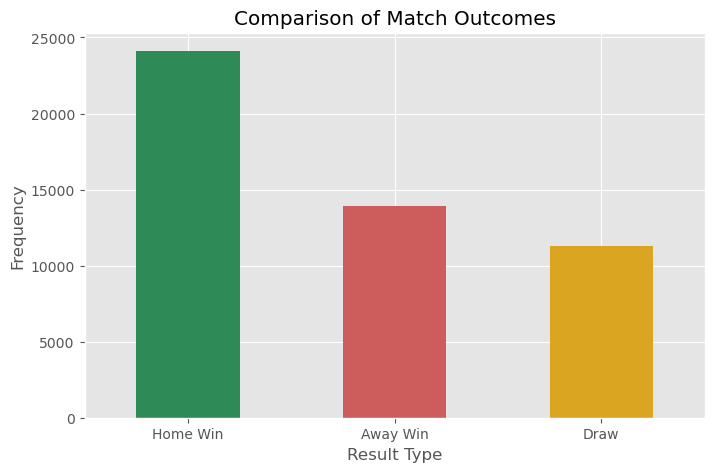

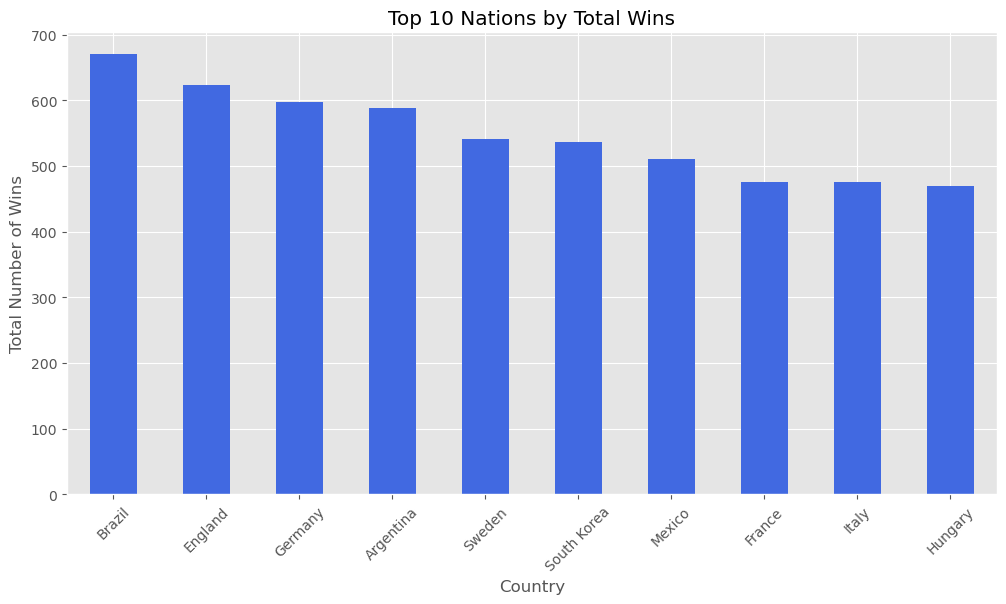

In [6]:
import matplotlib.pyplot as plt

# Set the style for the plots
plt.style.use('ggplot')

# 1. Histogram of goals
plt.figure(figsize=(10, 6))
df["total_goals"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Total Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.show()

# 2. Bar chart of match outcomes
plt.figure(figsize=(8, 5))
df["result"].value_counts().plot(kind="bar", color=['seagreen', 'indianred', 'goldenrod'])
plt.title("Comparison of Match Outcomes")
plt.xlabel("Result Type")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

# 3. Top 10 teams by total wins
plt.figure(figsize=(12, 6))
# We use the 'winner' column we created in the previous step
top_10_winners = df[df['winner'] != 'None']['winner'].value_counts().head(10)
top_10_winners.plot(kind="bar", color='royalblue')
plt.title("Top 10 Nations by Total Wins")
plt.xlabel("Country")
plt.ylabel("Total Number of Wins")
plt.xticks(rotation=45)
plt.show()